# **FINAL PROJECT REPORT**

## 1. Student Details

- Full name: Đỗ Phan Tuấn Đạt
- Student ID: 22127057

## 2. Course Details

- Course name: Statistical Machine learning
- Course ID: CSC15004

---

## 3. Project Details

- Chosen problem: Sentiment Analysis
- Chosen model: distilbert/distilbert-base-uncased
- Chosen dataset: GoEmotions

### 3.1. Problem Details

**Sentiment analysis**, also know as opinion mining, is a type of text classification that involves determining the emotional tone or attitude expressed in text. The simplest form of this problem features classifying texts into positive/neutral/negative tones. However, my project aims to train a model to identify specific emotions, so it is also reasonable to refer to this topic as **emotion analysis**.

### 3.2. Model Details

- Model name: distilbert/distilbert-base-uncased
- Source & Documentations: https://huggingface.co/distilbert/distilbert-base-uncased

The distiled version of Bert: A tranformer model pretrained on English using a masked language modeling (MLM) objective. The model is only 60% the size of a Bert model. However, it is said that the distiled version retains up to 97% the performance of the original version, while being 60% faster.
- Number of tensors: 67 million
- Pretraining type: self-supervised
- Variation: base (English, standard size) and uncased (not case sensitive when analysing text)

### 3.3. Dataset Details

- Dataset name: GoEmotions
- Source & Documentations: https://www.kaggle.com/datasets/debarshichanda/goemotions/data

The expanded version of the Google-released corpus of Reddit comments, annotated to 27 emotional states, or neutral, by humans.

Number of instances: **211225 rows**

Features in each instance:
- `text`: The text of the Reddit comment.
- `id`: The unique id of the comment.
- `author`: Username of the Redditor who wrote the comment.
- `subreddit`: The subreddit containing the thread in which the comment was written.
- `link_id`: The link id of the comment.
- `parent_id`: The parent id of the comment.
- `created_utc`: The timestamp of the comment.
- `rater_id`: The unique id of the human annotator who classified the comment.
- `example_very_unclear`: Whether the annotator marked the example as being very unclear or difficult to label, leading to no classification label selected.
- Separate columns representing each of the emotion categories, with binary labels (0 or 1). Featured emotion categories are: `admiration`, `amusement`, `anger`, `annoyance`, `approval`, `caring`, `confusion`, `curiosity`, `desire`, `disappointment`, `disapproval`, `disgust`, `embarrassment`, `excitement`, `fear`, `gratitude`, `grief`, `joy`, `love`, `nervousness`, `optimism`, `pride`, `realization`, `relief`, `remorse`, `sadness`, `surprise`, and `neutral`.

Every comment can express more than one emotional state (for example, both `pride` and `joy`), so the topic now becomes a multiclass and multilabel classification problem.

Data quality:
- The dataset has no missing value or duplicated instance.
- Apart from the original 58k carefully curated instances provided by Google, the rest of the dataset was labeled by an emotion pilot model, which was trained on reviewed examples.
- Quoted from documentation: "Potential biases in the data include: Inherent biases in Reddit and user base biases, the offensive/vulgar word lists used for data filtering, inherent or unconscious bias in assessment of offensive identity labels, annotators were all native English speakers from India. All these likely affect labelling, precision, and recall for a trained model."

---

## 4. Workflow

### 4.1. Data Preprocessing

- Source code: [data_preprocessing.ipynb](./scripts/data_preprocessing.ipynb)

**Pipeline:**
- Process duplicated objects: There weren't any
- Process missing values: There weren't any
- Extract useful columns: Apart from the text and the label columns, the other features in each row are only metadata, and would not contribute to the training. They were filtered out.
- Spliting dataset into training/validation/test sets: Ratio **80/10/10**, data is split in a way that respects original distribution of labels.
- Preprocessed datasets were then saved into separate csv files.

### 4.2. Model Training

- **Kaggle** notebook: https://www.kaggle.com/code/tdat94/notebook2453a914cf

**Pipeline:**
- Manual setup for running Kaggle notebook:
  - Run [onetime_model_download.py](./scripts/onetime_model_download.py) script to download base model into `models` folder locally.
  - Upload downloaded folder into Google Drive
  - Upload csv files containing datasets into Google Drive
  - [GG Drive folder containing model folder + dataset files](https://drive.google.com/drive/folders/1hG0UJ-prQKVHXtM9nY1962Nq-IS1M1ht?usp=sharing)
- Training model using Kaggle notebook:
  - Download model + datasets into notebook environment

### 4.3. Model Evaluation

Will be conducted below

In [1]:
# Import necessary libraries

import pandas as pd
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

c:\Users\HP\Desktop\Workspace\StatisticalLearning\finals\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Load data and model

test_df = pd.read_csv('data/test_data.csv')

model_dir = 'models/trained_emotion_model'
tokenizer = AutoTokenizer.from_pretrained(model_dir)
model = AutoModelForSequenceClassification.from_pretrained(model_dir)

In [3]:
# Get emotion columns
emotion_columns = [col for col in test_df.columns if col != 'text']

# Tokenize texts
inputs = tokenizer(
    test_df['text'].tolist(),
    padding=True,
    truncation=True,
    return_tensors='pt'
)

# True labels
y_true = test_df[emotion_columns].values

In [4]:
# Perform inference

batch_size = 128 # Split the inference into batches to avoid memory issues
all_preds = []
threshold = 0.5 # Threshold for classification

model.eval()
with torch.no_grad():
    for i in range(0, len(test_df), batch_size):
        batch_texts = test_df['text'].iloc[i:i+batch_size].tolist()
        batch_inputs = tokenizer(
            batch_texts,
            padding=True,
            truncation=True,
            return_tensors='pt'
        )
        outputs = model(**batch_inputs)
        logits = outputs.logits
        preds = (torch.sigmoid(logits).cpu().numpy() > threshold).astype(int)
        all_preds.append(preds)

y_pred = np.vstack(all_preds)

In [5]:
# CLassification report
report = classification_report(y_true, y_pred, target_names=emotion_columns)
print(report)

                precision    recall  f1-score   support

    admiration       0.66      0.45      0.54       853
     amusement       0.57      0.63      0.60       462
         anger       0.50      0.25      0.33       419
     annoyance       0.41      0.01      0.02       687
      approval       0.67      0.08      0.15       867
        caring       0.41      0.10      0.16       296
     confusion       0.65      0.16      0.26       384
     curiosity       0.53      0.15      0.24       462
        desire       0.69      0.06      0.11       192
disappointment       0.82      0.02      0.04       444
   disapproval       0.47      0.06      0.11       558
       disgust       0.62      0.09      0.16       269
 embarrassment       0.67      0.11      0.18       133
    excitement       0.65      0.12      0.20       276
          fear       0.72      0.26      0.38       147
     gratitude       0.90      0.76      0.82       558
         grief       0.00      0.00      0.00  

c:\Users\HP\Desktop\Workspace\StatisticalLearning\finals\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\HP\Desktop\Workspace\StatisticalLearning\finals\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [6]:
# Perform inference

batch_size = 128 # Split the inference into batches to avoid memory issues
all_preds = []
threshold = 0.8 # Threshold for classification

# For post-processing
neutral_idx = emotion_columns.index("neutral")
positive_emotions = [
    'admiration', 'amusement', 'approval', 'caring', 'excitement', 
    'gratitude', 'joy', 'love', 'optimism', 'pride', 'relief'
]
pos_idx = [emotion_columns.index(emotion) for emotion in positive_emotions]
neutral_emotions = [
    'confusion', 'curiosity', 'desire', 'realization', 'surprise', 'neutral'
]
negative_emotions = [
    'anger', 'annoyance', 'disappointment', 'disapproval', 'disgust', 
    'embarrassment', 'fear', 'grief', 'nervousness', 'remorse', 'sadness'
]
neg_idx = [emotion_columns.index(emotion) for emotion in negative_emotions]

model.eval()
with torch.no_grad():
    for i in range(0, len(test_df), batch_size):
        batch_texts = test_df['text'].iloc[i:i+batch_size].tolist()
        batch_inputs = tokenizer(
            batch_texts,
            padding=True,
            truncation=True,
            return_tensors='pt'
        )
        outputs = model(**batch_inputs)
        logits = outputs.logits.cpu().numpy()

        # Post-processing
        for row in logits:
            max_idx = np.argmax(row)
            if max_idx == neutral_idx:
                # Neutral is highest, set all others to -100
                row[:] = -100
                row[neutral_idx] = 100  # Ensure neutral is highest
            elif emotion_columns[max_idx] in positive_emotions:
                # Positive emotion is highest, set all negative emotions to -100
                for idx in neg_idx :
                    row[idx] = -100
                    row[neutral_idx] = -100 # Also set neutral to -100
            elif emotion_columns[max_idx] in negative_emotions:
                # Negative emotion is highest, set all positive emotions to -100
                for idx in pos_idx:
                    row[idx] = -100
                    row[neutral_idx] = -100 # Also set neutral to -100
            # No change for neutral_emotions

        preds = (torch.sigmoid(torch.from_numpy(logits)).cpu().numpy() > threshold).astype(int)

        # Additional post-processing: if no value reaches the thresholds, set the highest to 1
        for i, row in enumerate(preds):
            if row.sum() == 0:
                max_idx = np.argmax(logits[i])
                preds[i][max_idx] = 1

        all_preds.append(preds)

y_pred = np.vstack(all_preds)

In [7]:
# CLassification report
report = classification_report(y_true, y_pred, target_names=emotion_columns)
print(report)

                precision    recall  f1-score   support

    admiration       0.56      0.53      0.54       853
     amusement       0.54      0.68      0.60       462
         anger       0.38      0.47      0.42       419
     annoyance       0.26      0.17      0.20       687
      approval       0.49      0.15      0.24       867
        caring       0.39      0.27      0.32       296
     confusion       0.49      0.22      0.30       384
     curiosity       0.38      0.42      0.40       462
        desire       0.45      0.19      0.27       192
disappointment       0.38      0.06      0.11       444
   disapproval       0.29      0.23      0.25       558
       disgust       0.32      0.23      0.26       269
 embarrassment       0.45      0.20      0.28       133
    excitement       0.36      0.17      0.23       276
          fear       0.44      0.39      0.41       147
     gratitude       0.86      0.75      0.80       558
         grief       0.00      0.00      0.00  

c:\Users\HP\Desktop\Workspace\StatisticalLearning\finals\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


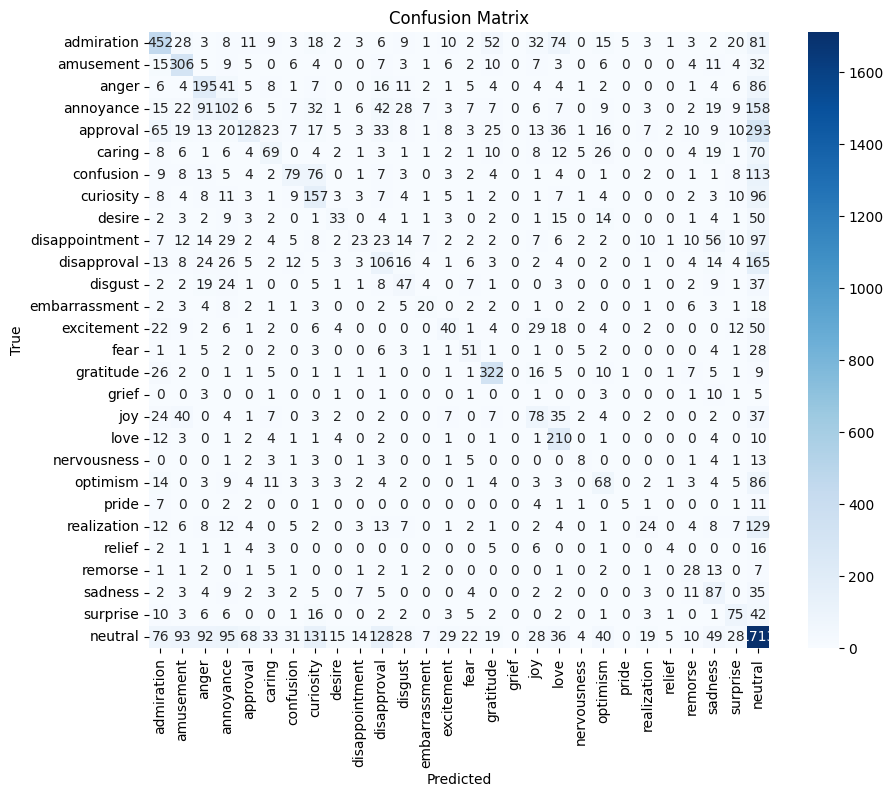

In [8]:
# Confusion matrix
cm = confusion_matrix(y_true.argmax(axis=1), y_pred.argmax(axis=1))
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=emotion_columns, yticklabels=emotion_columns)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

In [9]:
# Evaluate model performance accross 3 groups instead of the 28 labels

# Create new labels
y_true_grouped = np.zeros((y_true.shape[0], 3), dtype=int)
y_pred_grouped = np.zeros((y_pred.shape[0], 3), dtype=int)
for i in range(y_true.shape[0]):
    if y_true[i, neutral_idx] == 1:
        y_true_grouped[i, 0] = 1  # Neutral
    elif any(y_true[i, idx] == 1 for idx in pos_idx):
        y_true_grouped[i, 1] = 1  # Positive
    elif any(y_true[i, idx] == 1 for idx in neg_idx):
        y_true_grouped[i, 2] = 1  # Negative

for i in range(y_pred.shape[0]):
    if y_pred[i, neutral_idx] == 1:
        y_pred_grouped[i, 0] = 1  # Neutral
    elif any(y_pred[i, idx] == 1 for idx in pos_idx):
        y_pred_grouped[i, 1] = 1  # Positive
    elif any(y_pred[i, idx] == 1 for idx in neg_idx):
        y_pred_grouped[i, 2] = 1  # Negative
        
# Classification report for grouped emotions
grouped_emotions = ['Neutral', 'Positive', 'Negative']
report_grouped = classification_report(y_true_grouped, y_pred_grouped, target_names=grouped_emotions)
print(report_grouped)

              precision    recall  f1-score   support

     Neutral       0.49      0.61      0.54      2813
    Positive       0.78      0.69      0.73      3981
    Negative       0.61      0.58      0.59      2461

   micro avg       0.63      0.63      0.63      9255
   macro avg       0.63      0.62      0.62      9255
weighted avg       0.65      0.63      0.64      9255
 samples avg       0.56      0.56      0.56      9255



c:\Users\HP\Desktop\Workspace\StatisticalLearning\finals\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\HP\Desktop\Workspace\StatisticalLearning\finals\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in samples with no true labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\HP\Desktop\Workspace\StatisticalLearning\finals\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in samples with no true nor predicted labels. Use `zero_division` parameter to control this behavior.



---

## Reference Materials

- https://huggingface.co/datasets/google-research-datasets/go_emotions
- https://arxiv.org/abs/1910.01108